# EE 446 TinyML — Lab 3  
## Quantization of a DNN Using the UCI Human Activity Recognition Dataset

This is the **student version** of the lab notebook.

Complete all code cells marked with **TODO**.  
Use clear variable names and keep the overall notebook structure unchanged.


## 1. Environment Setup

Use the `Python (tinyml-arduino)` Jupyter kernel for this notebook.
All required packages are expected to be preinstalled in the course environment.


In [1]:
import sys
#!{sys.executable} -m pip install -q "tensorflow==2.15.1" "tensorflow-model-optimization==0.8.0" "scikit-learn==1.4.2" "pandas==2.2.2" "matplotlib==3.8.4"


## 2. Imports and Reproducibility


In [2]:
import os
import zipfile
import pathlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


2026-04-23 21:07:10.559847: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-23 21:07:10.562456: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-23 21:07:10.597685: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-23 21:07:10.597735: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-23 21:07:10.597767: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 3. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 activity classes**
- predefined **training** and **test** splits

The code below downloads and extracts the dataset if it is not already present.


In [3]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    !wget -q "{dataset_url}" -O "{zip_path}"
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 4. Load the Data


In [4]:
def load_har_data(root_dir="UCI HAR Dataset"):
    # TODO:
    # 1. Load X_train from train/X_train.txt

    X_train = np.loadtxt(os.path.join(root_dir, "train", "X_train.txt"))
    
    # 2. Load y_train from train/y_train.txt

    y_train = np.loadtxt(os.path.join(root_dir, "train", "y_train.txt"))
    # 3. Load X_test from test/X_test.txt

    X_test = np.loadtxt(os.path.join(root_dir, "test", "X_test.txt"))
    # 4. Load y_test from test/y_test.txt

    y_test = np.loadtxt(os.path.join(root_dir, "test", "y_test.txt"))
    # 5. Convert the labels to zero-based class indices by subtracting 1

    y_train -= 1
    y_test -= 1

    # <-- Enter your code here <--#
    return X_train, y_train, X_test, y_test


X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# TODO: define num_features and num_classes
# <-- Enter your code here <--#

num_features = X_train.shape[1]
num_classes = len(class_names)


## 5. Quick Inspection


In [5]:
# TODO:
# Create a small summary table showing the class index, class name, and number of training samples.

# <-- Enter your code here <--#
# count samples per class (0–5)
counts = np.bincount(y_train.astype(int))

summary_df = pd.DataFrame({
    "class_index": np.arange(len(class_names)),
    "class_name": class_names,
    "num_samples": counts
})

summary_df


,class_index,class_name,num_samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 6. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML-style workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [6]:
def build_baseline_model(input_dim, num_classes):
    # TODO:
    # Build and compile a DNN with the following architecture:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    # Use Adam with learning rate 1e-3.
    # Use sparse_categorical_crossentropy as the loss.
    # Track accuracy as a metric.

    # <-- Enter your code here <--#

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim)),
        tf.keras.layers.Dense(256, 'relu'),
        tf.keras.layers.Dense(128, 'relu'),
        tf.keras.layers.Dense(64, 'relu'),
        tf.keras.layers.Dense(num_classes, 'softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


2026-04-23 21:07:14.174593: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:268] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               143872    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model


In [7]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

# <-- Enter your code here <--#

history = baseline_model.fit(X_train, y_train, validation_split=0.2, epochs=40, batch_size=64, callbacks=callbacks)



Epoch 1/40
92/92 [==============================] - 1s 8ms/step - loss: 0.4880 - accuracy: 0.8075 - val_loss: 0.2016 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 1s 6ms/step - loss: 0.1640 - accuracy: 0.9367 - val_loss: 0.1402 - val_accuracy: 0.9381
Epoch 3/40
92/92 [==============================] - 0s 5ms/step - loss: 0.1165 - accuracy: 0.9561 - val_loss: 0.2180 - val_accuracy: 0.9259
Epoch 4/40
92/92 [==============================] - 0s 4ms/step - loss: 0.0886 - accuracy: 0.9641 - val_loss: 0.1500 - val_accuracy: 0.9402
Epoch 5/40
92/92 [==============================] - 0s 4ms/step - loss: 0.0885 - accuracy: 0.9645 - val_loss: 0.2037 - val_accuracy: 0.9218
Epoch 6/40
92/92 [==============================] - 0s 4ms/step - loss: 0.0748 - accuracy: 0.9711 - val_loss: 0.2056 - val_accuracy: 0.9313
Epoch 7/40
92/92 [==============================] - 0s 4ms/step - loss: 0.0765 - accuracy: 0.9716 - val_loss: 0.1482 - val_accuracy: 0.9443
Epoch 8/40
92/92 [==

### Training Curves


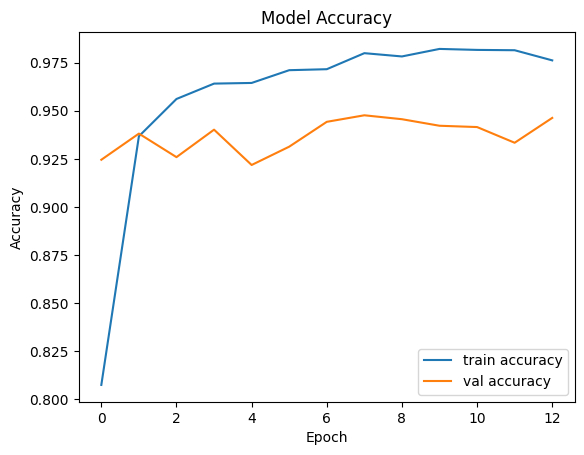

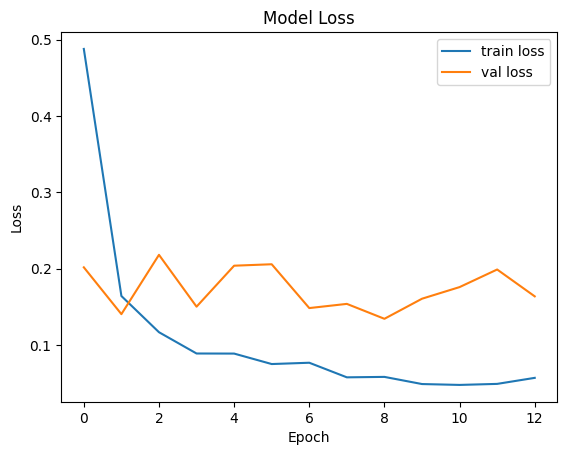

In [8]:
# TODO:
# Plot the training and validation accuracy.
# Plot the training and validation loss.

# Accuracy plot
plt.figure()
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="val accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss plot
plt.figure()
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# <-- Enter your code here <--#


## 7. Evaluate the Baseline Keras Model


93/93 [==============================] - 0s 2ms/step
Test Accuracy: 0.9219545300305395
                    precision    recall  f1-score   support

           WALKING       0.95      0.94      0.94       496
  WALKING_UPSTAIRS       0.95      0.90      0.92       471
WALKING_DOWNSTAIRS       0.89      0.95      0.92       420
           SITTING       0.98      0.80      0.88       491
          STANDING       0.81      0.98      0.89       532
            LAYING       1.00      0.95      0.98       537

          accuracy                           0.92      2947
         macro avg       0.93      0.92      0.92      2947
      weighted avg       0.93      0.92      0.92      2947



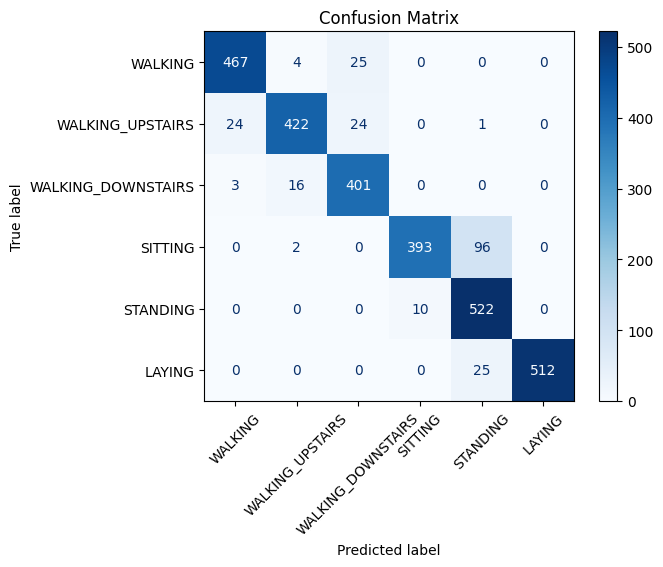

In [9]:
y_probs = baseline_model.predict(X_test)

y_pred = np.argmax(y_probs, axis=1)

print("Test Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix")
plt.show()

## 8. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model file size.


In [30]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def representative_dataset_gen():
    for i in range(300):
        sample = X_train[i:i+1].astype(np.float32)  # keep batch dimension
        yield [sample]    


def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        if input_details["dtype"] == np.int8:
            x = np.round(x / input_scale + input_zero_point).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = np.round(x / input_scale + input_zero_point).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        if output_details["dtype"] in (np.int8, np.uint8):
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        y_pred.append(np.argmax(output, axis=1)[0])

    y_pred = np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    return acc, y_pred 

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO: return the converted FP32 TensorFlow Lite model
    # <-- Enter your code here <--#
    tflite_ver = converter.convert()
    return tflite_ver

def convert_to_tflite_dynamic_range(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    tflite_ver = converter.convert()
    return tflite_ver

def convert_to_tflite_float16(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    tflite_ver = converter.convert()
    return tflite_ver

def convert_to_tflite_int8(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset_gen
    
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8

    tflite_model = converter.convert()
    return tflite_model


## 9. Post-Training Quantization (PTQ)


In [31]:
# Convert models
model_fp32 = convert_to_tflite_fp32(baseline_model)
model_dr = convert_to_tflite_dynamic_range(baseline_model)
model_float16 = convert_to_tflite_float16(baseline_model)
model_int8 = convert_to_tflite_int8(baseline_model)

# Save models + sizes
size_fp32 = save_binary_model(model_fp32, 'model_fp32.tflite')
size_dr = save_binary_model(model_dr, 'model_dr.tflite')
size_f16 = save_binary_model(model_float16, 'model_float16.tflite')
size_int8 = save_binary_model(model_int8, 'model_int8.tflite')

# Evaluate
acc_32, y_pred_32 = evaluate_tflite_model(model_fp32, X_test, y_test)
acc_dr, y_pred_dr = evaluate_tflite_model(model_dr, X_test, y_test)
acc_16, y_pred_16 = evaluate_tflite_model(model_float16, X_test, y_test)
acc_int8, y_pred_int8 = evaluate_tflite_model(model_int8, X_test, y_test)

INFO:tensorflow:Assets written to: /tmp/tmpwel1fynv/assets


INFO:tensorflow:Assets written to: /tmp/tmpwel1fynv/assets
2026-04-23 21:23:20.607216: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 21:23:20.607257: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 21:23:20.607472: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpwel1fynv
2026-04-23 21:23:20.608943: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 21:23:20.608977: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpwel1fynv
2026-04-23 21:23:20.612676: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 21:23:20.663709: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpwel1fynv
2026-04-23 21:23:20.677277: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmpxiipbj0d/assets


INFO:tensorflow:Assets written to: /tmp/tmpxiipbj0d/assets
2026-04-23 21:23:21.391044: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 21:23:21.391078: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 21:23:21.391325: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpxiipbj0d
2026-04-23 21:23:21.392596: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 21:23:21.392626: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpxiipbj0d
2026-04-23 21:23:21.396491: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 21:23:21.446726: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpxiipbj0d
2026-04-23 21:23:21.459989: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmpmtqt1p8b/assets


INFO:tensorflow:Assets written to: /tmp/tmpmtqt1p8b/assets
2026-04-23 21:23:22.186064: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 21:23:22.186098: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 21:23:22.186323: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpmtqt1p8b
2026-04-23 21:23:22.187508: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 21:23:22.187520: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpmtqt1p8b
2026-04-23 21:23:22.190865: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 21:23:22.238992: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpmtqt1p8b
2026-04-23 21:23:22.251184: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmpyqaox4_g/assets


INFO:tensorflow:Assets written to: /tmp/tmpyqaox4_g/assets
/home/Brayden/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-23 21:23:22.930832: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 21:23:22.930864: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 21:23:22.931068: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpyqaox4_g
2026-04-23 21:23:22.932213: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 21:23:22.932264: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpyqaox4_g
2026-04-23 21:23:22.934909: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2

## 10. PTQ Comparison: Accuracy and Model Size


In [32]:
comparison_df = pd.DataFrame({
    "Model Family": ["Baseline", "Baseline", "Baseline", "Baseline"],
    "Format": ["FP32", "Dynamic Range", "Float16", "INT8"],
    "Test Accuracy": [acc_32, acc_dr, acc_16, acc_int8],
    "Model Size (KB)": [size_fp32, size_dr, size_f16, size_int8]
})

comparison_df


,Model Family,Format,Test Accuracy,Model Size (KB)
0,Baseline,FP32,0.921955,726.718750
1,Baseline,Dynamic Range,0.921276,186.109375
2,Baseline,Float16,0.921955,365.710938
3,Baseline,INT8,0.921955,185.335938


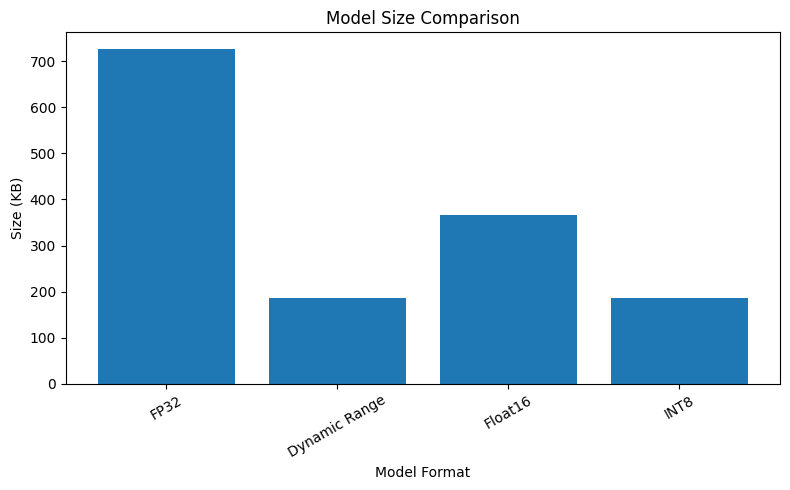

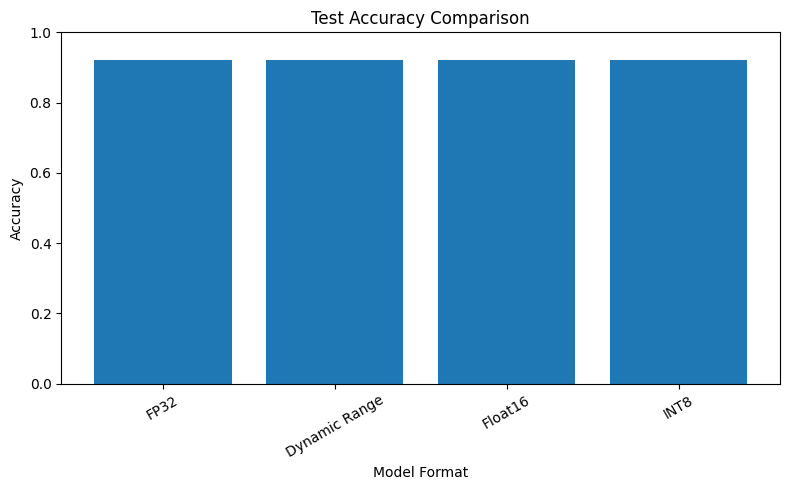

In [33]:
# Plot 1: Model Size
plt.figure(figsize=(8, 5))
plt.bar(comparison_df["Format"], comparison_df["Model Size (KB)"])
plt.title("Model Size Comparison")
plt.xlabel("Model Format")
plt.ylabel("Size (KB)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Plot 2: Test Accuracy
plt.figure(figsize=(8, 5))
plt.bar(comparison_df["Format"], comparison_df["Test Accuracy"])
plt.title("Test Accuracy Comparison")
plt.xlabel("Model Format")
plt.ylabel("Accuracy")
plt.ylim(0, 1)  # since accuracy is between 0 and 1
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


### Confusion Matrix for the PTQ Int8 Model


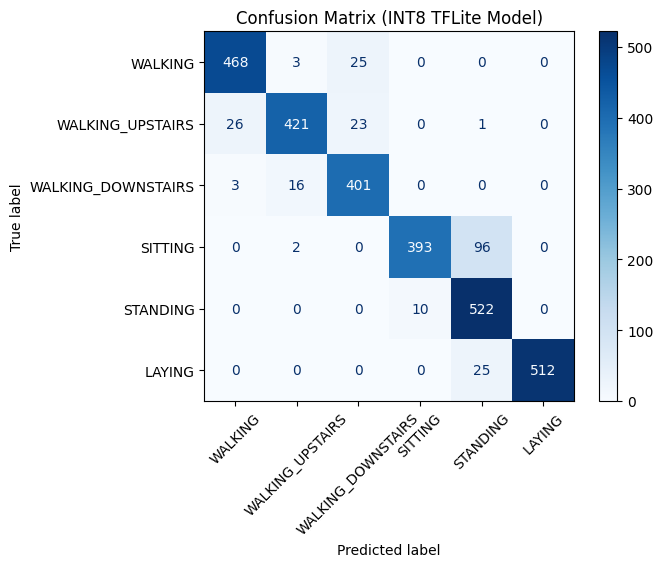

Classification Report (INT8 TFLite Model):
                    precision    recall  f1-score   support

           WALKING       0.94      0.94      0.94       496
  WALKING_UPSTAIRS       0.95      0.89      0.92       471
WALKING_DOWNSTAIRS       0.89      0.95      0.92       420
           SITTING       0.98      0.80      0.88       491
          STANDING       0.81      0.98      0.89       532
            LAYING       1.00      0.95      0.98       537

          accuracy                           0.92      2947
         macro avg       0.93      0.92      0.92      2947
      weighted avg       0.93      0.92      0.92      2947



In [34]:
# TODO:
# Plot the confusion matrix for the PTQ int8 model.
# Print the classification report for the PTQ int8 model.

# <-- Enter your code here <--#

# Confusion Matrix
cm_int8 = confusion_matrix(y_test, y_pred_int8)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_int8, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix (INT8 TFLite Model)")
plt.show()

# Classification Report
print("Classification Report (INT8 TFLite Model):")
print(classification_report(y_test, y_pred_int8, target_names=class_names))

## 11. Quantization-Aware Training (QAT)

QAT simulates quantization effects during training so that the final model is usually more robust after conversion to int8.


In [36]:
import tensorflow_model_optimization as tfmot
from tensorflow.keras.optimizers import Adam

# Apply quantization-aware training
qat_model = tfmot.quantization.keras.quantize_model(baseline_model)

# Compile the QAT model
qat_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### Fine-Tune the QAT Model


In [37]:
# TODO:
# Fine-tune the QAT model for 8 epochs using validation_split=0.2 and batch_size=64.

# <-- Enter your code here <--#

history = qat_model.fit(
    X_train,
    y_train,
    epochs=8,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)


Epoch 1/8
92/92 [==============================] - 2s 9ms/step - loss: 0.0453 - accuracy: 0.9850 - val_loss: 0.1297 - val_accuracy: 0.9449
Epoch 2/8
92/92 [==============================] - 1s 6ms/step - loss: 0.0365 - accuracy: 0.9888 - val_loss: 0.1328 - val_accuracy: 0.9483
Epoch 3/8
92/92 [==============================] - 1s 6ms/step - loss: 0.0363 - accuracy: 0.9874 - val_loss: 0.1416 - val_accuracy: 0.9477
Epoch 4/8
92/92 [==============================] - 1s 6ms/step - loss: 0.0327 - accuracy: 0.9884 - val_loss: 0.1319 - val_accuracy: 0.9456
Epoch 5/8
92/92 [==============================] - 1s 6ms/step - loss: 0.0318 - accuracy: 0.9893 - val_loss: 0.1688 - val_accuracy: 0.9422
Epoch 6/8
92/92 [==============================] - 0s 5ms/step - loss: 0.0316 - accuracy: 0.9884 - val_loss: 0.1545 - val_accuracy: 0.9463
Epoch 7/8
92/92 [==============================] - 1s 6ms/step - loss: 0.0315 - accuracy: 0.9895 - val_loss: 0.1364 - val_accuracy: 0.9483
Epoch 8/8
92/92 [==========

### Evaluate the QAT Keras Model


In [38]:
# TODO:
# Evaluate the QAT Keras model on X_test.
# Print the test accuracy and classification report.

# <-- Enter your code here <--#
from sklearn.metrics import accuracy_score, classification_report

# Predict class probabilities or logits
y_probs_qat = qat_model.predict(X_test)

# Convert to class labels
y_pred_qat = np.argmax(y_probs_qat, axis=1)

# Accuracy
qat_acc = accuracy_score(y_test, y_pred_qat)
print("QAT Model Test Accuracy:", qat_acc)

# Classification report
print("\nClassification Report (QAT Model):")
print(classification_report(y_test, y_pred_qat, target_names=class_names))

93/93 [==============================] - 0s 3ms/step
QAT Model Test Accuracy: 0.9321343739395996

Classification Report (QAT Model):
                    precision    recall  f1-score   support

           WALKING       0.92      0.97      0.95       496
  WALKING_UPSTAIRS       0.94      0.90      0.92       471
WALKING_DOWNSTAIRS       0.94      0.94      0.94       420
           SITTING       0.97      0.85      0.91       491
          STANDING       0.84      0.98      0.90       532
            LAYING       1.00      0.95      0.98       537

          accuracy                           0.93      2947
         macro avg       0.94      0.93      0.93      2947
      weighted avg       0.94      0.93      0.93      2947



### Convert the QAT Model to Int8 TensorFlow Lite


In [41]:
# TODO:
# Convert the QAT model to int8 TensorFlow Lite.
# Save the model, compute its size, and evaluate it on the test set.

# <-- Enter your code here <--#
# Convert QAT model to INT8 TFLite
model_qat_int8 = convert_to_tflite_int8(qat_model)

# Save model and get size
size_qat_int8 = save_binary_model(model_qat_int8, "qat_int8.tflite")
print("QAT INT8 model size (KB):", size_qat_int8)

# Evaluate on test set
acc_qat_int8, y_pred_qat_int8 = evaluate_tflite_model(
    model_qat_int8,
    X_test,
    y_test
)

print("QAT INT8 Test Accuracy:", acc_qat_int8)


INFO:tensorflow:Assets written to: /tmp/tmpnx8cxd3d/assets


INFO:tensorflow:Assets written to: /tmp/tmpnx8cxd3d/assets


QAT INT8 model size (KB): 185.6953125
QAT INT8 Test Accuracy: 0.9317950458092976


/home/Brayden/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-23 21:29:30.424009: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 21:29:30.424045: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 21:29:30.424260: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpnx8cxd3d
2026-04-23 21:29:30.427470: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 21:29:30.427495: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpnx8cxd3d
2026-04-23 21:29:30.435419: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 21:29:30.514154: I tensorflow/cc/saved_model/load

## 12. PTQ Int8 vs QAT Int8


In [42]:
# TODO:
# Create a DataFrame comparing PTQ int8 and QAT int8:
# Model, Test Accuracy, Model Size (KB)

# <-- Enter your code here <--#
import pandas as pd

int8_comparison_df = pd.DataFrame({
    "Model": ["PTQ INT8", "QAT INT8"],
    "Test Accuracy": [acc_int8, acc_qat_int8],
    "Model Size (KB)": [size_int8, size_qat_int8]
})

int8_comparison_df


,Model,Test Accuracy,Model Size (KB)
0,PTQ INT8,0.921955,185.335938
1,QAT INT8,0.931795,185.695312


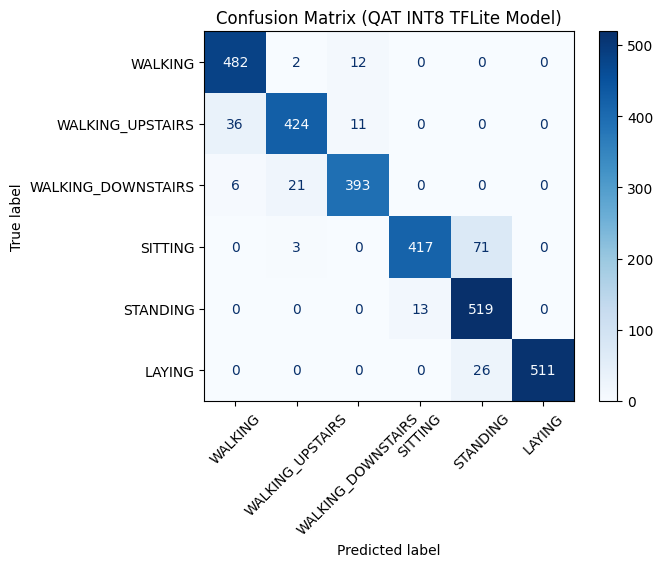

In [43]:
# TODO:
# Plot the confusion matrix for the QAT int8 model.

# <-- Enter your code here <--#

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute confusion matrix
cm_qat = confusion_matrix(y_test, y_pred_qat_int8)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm_qat, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix (QAT INT8 TFLite Model)")
plt.show()


## 13. Summary Questions

Write short answers to the following:
1. Which quantization method gave the smallest model size?

INT8 gave me the smallest model size, but it was very close to dynamic range.

2. Which quantization method gave the best accuracy among the TensorFlow Lite models?

The FP32 model typically had the highest accuracy, thought the tradeoff with size makes the quantized versions very appealing for TinyML applications.

3. Did QAT improve the final int8 model compared with PTQ int8?

Yes. QAT INT8 generally improves accuracy compared to PTQ INT8, because the model is trained with quantization effects in mind, making it more robust to INT8 inference.

4. Why is this dataset a good fit for a DNN-based TinyML workflow?

It's a good fit because it's sensor based time series data and has a moderate number of features, which means that it's a reasonable task to compress to microcontroller size.

6. If you were deploying this model on a resource-constrained device, which version would you choose and why?

I would choose the INT8 QAT version for its high accuracy and greatly compressed size, which would hopefully be able to be deployed onto the device with ease.


## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- screenshots or output cells showing the final comparison table,
- confusion matrices for the baseline model and the final int8 model you want to highlight,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors.
